In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install kmodes


In [3]:
import numpy as np
import pandas as pd
from sklearn import metrics, preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from kmodes.kmodes import KModes
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
# helper function for models evaluation adn performance comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, multilabel_confusion_matrix, classification_report

def evaluate_model(model,model_Name, x_val, y_val):
    # Evaluate the model
    y_pred_probs = model.predict(x_val)
    # Convert probabilities to binary class labels based on a threshold (e.g., 0.5)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred_classes)
    precision = precision_score(y_val, y_pred_classes, average='micro')
    recall = recall_score(y_val, y_pred_classes, average='micro')
    f1 = f1_score(y_val, y_pred_classes, average='micro')
    # Create DataFrame to store metrics
    metrics_df = pd.DataFrame({
        'Model': [model_Name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1]
    })

    return metrics_df


In [5]:
file_path = '/content/drive/My Drive/heart.csv'
df = pd.read_csv(file_path, sep=',', encoding='utf-8')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [ ]:
print(df.isnull().sum())

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64


**demographic details**

In [ ]:
import pandas as pd

# =======================
# 1. CLASS DISTRIBUTION
# =======================
print("===== CLASS DISTRIBUTION =====")
class_counts = df['target'].value_counts()
class_percent = df['target'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent.round(2)
}))
print("\n")

# =======================
# 2. AGE STATISTICS
# Use correct column ↓
# =======================
age_col = "age" if "age" in df.columns else "age_bin"

print("Using age column:", age_col)

print("===== AGE STATISTICS =====")
print(f"Mean age: {df[age_col].mean():.2f}")
print(f"SD age:   {df[age_col].std():.2f}")
print(f"Min age:  {df[age_col].min()}")
print(f"Max age:  {df[age_col].max()}")
print("\n")

# =======================
# 3. GENDER DISTRIBUTION
# =======================
print("===== GENDER DISTRIBUTION =====")
gender_counts = df['sex'].value_counts()
gender_percent = df['sex'].value_counts(normalize=True) * 100

gender_table = pd.DataFrame({
    "Count": gender_counts,
    "Percent": gender_percent.round(2)
})

gender_table.index = ["Female (0)", "Male (1)"]
print(gender_table)
print("\n")


===== CLASS DISTRIBUTION =====
        Count  Percent
target                
1         629    52.86
0         561    47.14


Using age column: age
===== AGE STATISTICS =====
Mean age: 53.72
SD age:   9.36
Min age:  28
Max age:  77


===== GENDER DISTRIBUTION =====
            Count  Percent
Female (0)    909    76.39
Male (1)      281    23.61




In [ ]:
import pandas as pd
import numpy as np

# If you want to load from a CSV, uncomment and change the path:
# df = pd.read_csv("path/to/your/data.csv")

# -- assume df already exists in the environment (as in your notebook) --
# If not present, create a tiny example to avoid NameError (remove this in real use)
if 'df' not in globals():
    df = pd.DataFrame({
        "age": np.random.randint(28, 78, 100),
        "sex": np.random.choice([0,1], 100, p=[0.25,0.75]),
        "chest pain type": np.random.choice([1,2,3,4], 100),
        "resting bp s": np.random.randint(90, 180, 100),
        "cholesterol": np.random.randint(100, 300, 100),
        "fasting blood sugar": np.random.choice([0,1], 100, p=[0.8,0.2]),
        "resting ecg": np.random.choice([0,1,2], 100),
        "max heart rate": np.random.randint(60, 200, 100),
        "exercise angina": np.random.choice([0,1], 100, p=[0.6,0.4]),
        "oldpeak": np.round(np.random.uniform(-2.5, 6.5, 100), 2),
        "ST slope": np.random.choice([0,1,2,3], 100),
        "target": np.random.choice([0,1], 100, p=[0.48,0.52])
    })

# ---------------------------
# Helper functions & maps
# ---------------------------
def print_counts_percent(series, index_map=None, top_n=None):
    counts = series.value_counts(dropna=False)
    perc = series.value_counts(normalize=True, dropna=False) * 100
    table = pd.DataFrame({"Count": counts.astype(int), "Percent": perc.round(2)})
    if index_map:
        # map index labels where possible (only for exact keys)
        new_index = [index_map.get(idx, idx) for idx in table.index]
        table.index = new_index
    if top_n:
        print(table.head(top_n))
    else:
        print(table)
    print()

def numeric_summary(series):
    s = series.dropna().astype(float)
    mean = s.mean()
    std = s.std()
    med = s.median()
    mn = s.min()
    mx = s.max()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    # Print in Mean ± SD style plus other stats
    print(f"Mean ± SD: {mean:.2f} ± {std:.2f}")
    print(f"Median:    {med:.2f}")
    # If values are integers (close to ints), print as ints for min/max
    if float(mn).is_integer() and float(mx).is_integer():
        print(f"Min:       {int(mn)}")
        print(f"Max:       {int(mx)}")
    else:
        print(f"Min:       {mn}")
        print(f"Max:       {mx}")
    print(f"IQR:       {iqr:.2f} (Q1={q1:.2f}, Q3={q3:.2f})")
    print()

def select_map(series, candidate_maps):
    """Return the first mapping from candidate_maps whose keys cover all series values."""
    vals = set(series.dropna().unique())
    for m in candidate_maps:
        if vals.issubset(set(m.keys())):
            return m
    return None

# Candidate mappings (do not apply unless the data values are a subset)
sex_map = {0: "Female (0)", 1: "Male (1)"}
exercise_angina_map = {0: "No (0)", 1: "Yes (1)"}
fbs_map = {0: "False (0)", 1: "True (1)"}  # fasting blood sugar > 120 mg/dl

# chest pain: two common codings exist in datasets:
chest_map_1to4 = {
    1: "typical angina (1)",
    2: "atypical angina (2)",
    3: "non-anginal pain (3)",
    4: "asymptomatic (4)"
}
chest_map_0to3 = {
    0: "typical angina (0)",
    1: "atypical angina (1)",
    2: "non-anginal pain (2)",
    3: "asymptomatic (3)"
}

rest_ecg_map = {0: "Normal (0)", 1: "ST-T wave abnormality (1)", 2: "Left ventricular hypertrophy (2)"}
# ST slope: include 0..3 just in case your dataset contains all four codes
st_slope_map = {
    0: "Undefined (0)",
    1: "Upsloping (1)",
    2: "Flat (2)",
    3: "Downsloping (3)"
}

# ---------------------------
# Columns & main loop
# ---------------------------
# Do NOT include 'target' here to avoid duplicate printing (we print it in recap)
cols = [
    "age", "sex", "chest pain type", "resting bp s", "cholesterol",
    "fasting blood sugar", "resting ecg", "max heart rate",
    "exercise angina", "oldpeak", "ST slope"
]

print("===== FULL DEMOGRAPHIC SUMMARY =====\n")

for col in cols:
    if col not in df.columns:
        # skip missing columns silently
        continue

    print(f"--- Column: {col} ---")
    series = df[col]

    # Decide categorical vs numeric:
    is_numeric = pd.api.types.is_numeric_dtype(series)
    unique_count = series.nunique(dropna=True)

    # Heuristic: numeric columns with many uniques -> numeric; small uniques -> categorical
    if is_numeric and unique_count > 10 and col not in ["sex", "target"]:
        numeric_summary(series)
    elif col in ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]:
        numeric_summary(series)
    else:
        # categorical summary: choose an index_map only if series values match a map's keys
        index_map = None
        # Try appropriate candidate maps
        if col == "sex":
            index_map = select_map(series, [sex_map])
        elif col == "exercise angina":
            index_map = select_map(series, [exercise_angina_map])
        elif col == "fasting blood sugar":
            index_map = select_map(series, [fbs_map])
        elif col == "chest pain type":
            index_map = select_map(series, [chest_map_1to4, chest_map_0to3])
        elif col == "resting ecg":
            index_map = select_map(series, [rest_ecg_map])
        elif col == "ST slope":
            index_map = select_map(series, [st_slope_map])

        print_counts_percent(series, index_map=index_map)

# Print target once as final recap
if "target" in df.columns:
    print("===== TARGET (RECAP) =====")
    print_counts_percent(df["target"])


===== FULL DEMOGRAPHIC SUMMARY =====

--- Column: age ---
Mean ± SD: 53.72 ± 9.36
Median:    54.00
Min:       28
Max:       77
IQR:       13.00 (Q1=47.00, Q3=60.00)

--- Column: sex ---
            Count  Percent
Male (1)      909    76.39
Female (0)    281    23.61

--- Column: chest pain type ---
                      Count  Percent
asymptomatic (4)        625    52.52
non-anginal pain (3)    283    23.78
atypical angina (2)     216    18.15
typical angina (1)       66     5.55

--- Column: resting bp s ---
Mean ± SD: 132.15 ± 18.37
Median:    130.00
Min:       0
Max:       200
IQR:       20.00 (Q1=120.00, Q3=140.00)

--- Column: cholesterol ---
Mean ± SD: 210.36 ± 101.42
Median:    229.00
Min:       0
Max:       603
IQR:       81.75 (Q1=188.00, Q3=269.75)

--- Column: fasting blood sugar ---
           Count  Percent
False (0)    936    78.66
True (1)     254    21.34

--- Column: resting ecg ---
                                  Count  Percent
Normal (0)                          68

**Binning age column**

In [6]:
print(df['age'].dtype)
print(df['age'].unique())
print(df['age'].isna().sum())


int64
[40 49 37 48 54 39 45 58 42 38 43 60 36 44 53 52 51 56 41 32 65 35 59 50
 47 31 46 57 55 63 66 34 33 61 29 62 28 30 74 68 72 64 69 67 73 70 77 75
 76 71]
0


In [7]:
# Step 1: Bin the age values
df['age_bin'] = pd.cut(df['age'],
                       bins=[27, 39, 49, 59, 69, 77],
                       labels=[0, 1, 2, 3, 4],
                       include_lowest=True)

# Step 2: Check how many are NaN
print("Missing after binning:", df['age_bin'].isna().sum())

# Step 3: Drop rows with NaN in age_bin
df = df[df['age_bin'].notna()]

# Step 4: Convert to int
df['age_bin'] = df['age_bin'].astype(int)

# Step 5: Drop original age
df.drop('age', axis=1, inplace=True)


Missing after binning: 0


In [8]:
print(df[['age_bin']].head(10))


   age_bin
0        1
1        1
2        0
3        1
4        2
5        0
6        1
7        2
8        0
9        1


In [9]:
df = df.fillna(df.mean())

In [10]:
df['sex'] = df['sex'].astype('category')  # Example: Ensure `sex` is categorical
df = pd.get_dummies(df, columns=['chest pain type', 'resting ecg', 'ST slope'], drop_first=True)


In [11]:
df = df.apply(pd.to_numeric, errors='coerce')


In [12]:
print(df.head())  # View cleaned data
print(df.info())  # Check data types and ensure numeric types


   sex  resting bp s  cholesterol  fasting blood sugar  max heart rate  \
0    1           140          289                    0             172   
1    0           160          180                    0             156   
2    1           130          283                    0              98   
3    0           138          214                    0             108   
4    1           150          195                    0             122   

   exercise angina  oldpeak  target  age_bin  chest pain type_2  \
0                0      0.0       0        1               True   
1                0      1.0       1        1              False   
2                0      0.0       0        0               True   
3                1      1.5       1        1              False   
4                0      0.0       0        2              False   

   chest pain type_3  chest pain type_4  resting ecg_1  resting ecg_2  \
0              False              False          False          False   
1     

**Train test split**

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])   # use your actual target column name
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


**StandardScaler — FIT on TRAIN only**

In [14]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['age_bin', 'resting bp s', 'cholesterol',
                    'max heart rate', 'oldpeak']

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)


## **Clustering**

In [15]:
cost = []
num_clusters = range(1, 6)  # 1 to 5

for i in num_clusters:
    kmode = KModes(
        n_clusters=i,
        init="Huang",
        n_init=5,
        verbose=0,
        random_state=1
    )

    kmode.fit_predict(X_train)   # ✅ training data only
    cost.append(kmode.cost_)


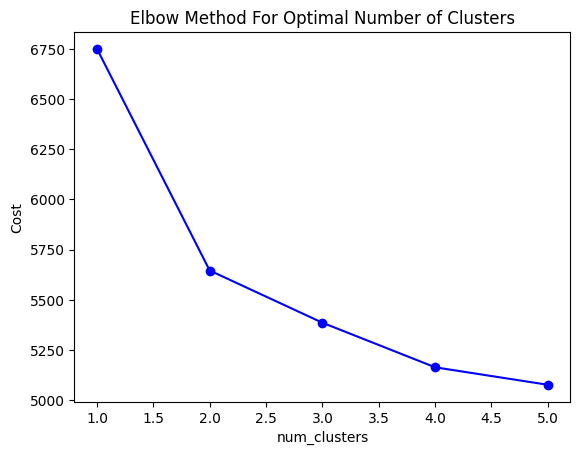

In [16]:
plt.plot(num_clusters, cost, 'bo-')
plt.xlabel('num_clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.show()


In [17]:
km = KModes(
    n_clusters=2,
    init="Huang",
    n_init=5,
    random_state=1
)

train_clusters = km.fit_predict(X_train)   # ✅ fit ONLY on training data
test_clusters = km.predict(X_test)         # ✅ assign clusters to test data

train_clusters, test_clusters


(array([0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
        0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
        1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
        1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
        0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 

In [18]:
X_train = X_train.drop(columns=['clusters'], errors='ignore')
X_test = X_test.drop(columns=['clusters'], errors='ignore')

X_train.insert(0, 'clusters', train_clusters)
X_test.insert(0, 'clusters', test_clusters)

print(X_train.columns)
print(X_test.columns)


Index(['clusters', 'sex', 'resting bp s', 'cholesterol', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'age_bin',
       'chest pain type_2', 'chest pain type_3', 'chest pain type_4',
       'resting ecg_1', 'resting ecg_2', 'ST slope_1', 'ST slope_2',
       'ST slope_3'],
      dtype='object')
Index(['clusters', 'sex', 'resting bp s', 'cholesterol', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'age_bin',
       'chest pain type_2', 'chest pain type_3', 'chest pain type_4',
       'resting ecg_1', 'resting ecg_2', 'ST slope_1', 'ST slope_2',
       'ST slope_3'],
      dtype='object')


In [19]:
len(train_clusters) == len(X_train)
len(test_clusters) == len(X_test)


True

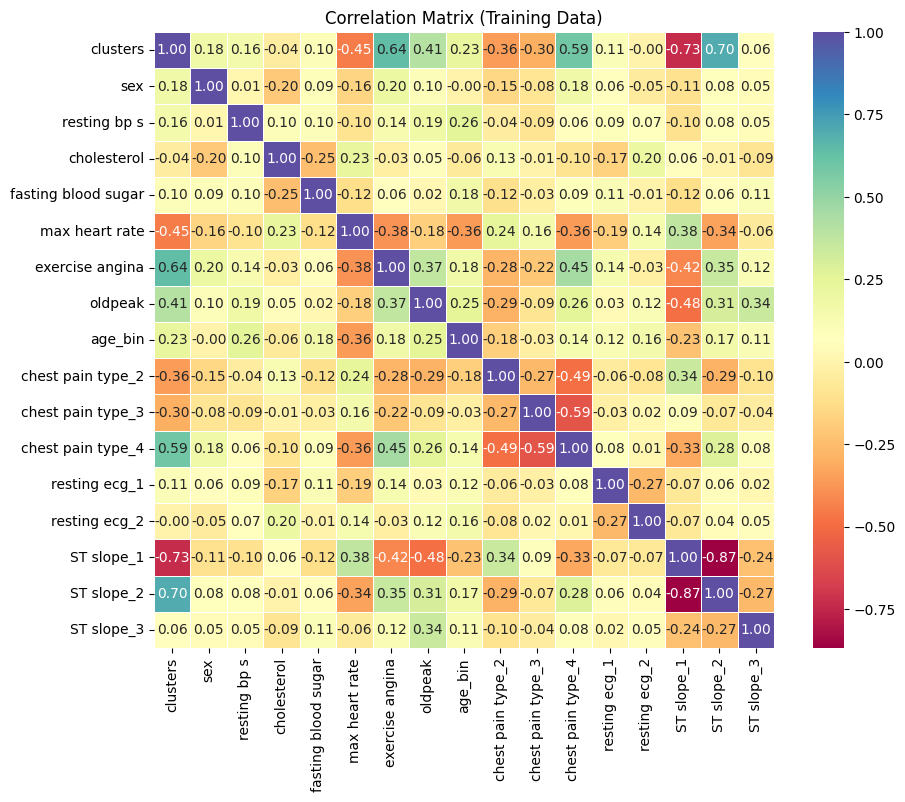

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, cmap='Spectral', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix (Training Data)')
plt.show()


In [21]:
pd.crosstab(X_train["clusters"], y_train)



target,0,1
clusters,,
0,393,132
1,56,371


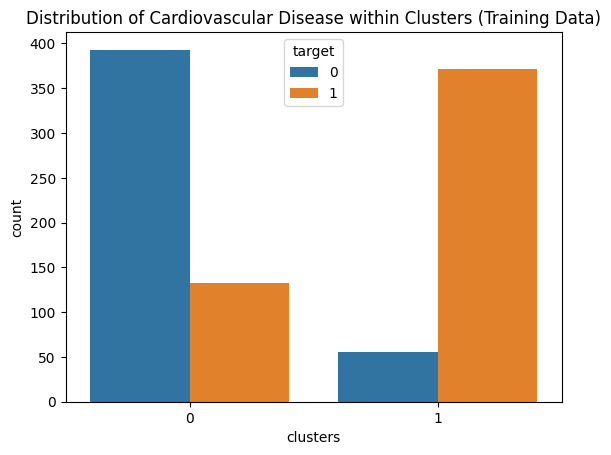

In [22]:
sns.countplot(
    x='clusters',
    hue=y_train,
    data=X_train
)
plt.title('Distribution of Cardiovascular Disease within Clusters (Training Data)')
plt.show()


In [ ]:
print(f"Number of training samples: {len(X_train)}")
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of training samples: {len(y_train)}")
print(f"Number of testing samples: {len(y_test)}")


Number of training samples: 952
Number of testing samples: 238
Number of training samples: 952
Number of testing samples: 238


# **Models Implementation**

### **Simple feed forward Neural network**

In [23]:
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split

# Create validation split from TRAINING DATA ONLY
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Build model
model_simple = Sequential()
model_simple.add(Dense(64, activation='relu', input_shape=(X_tr.shape[1],)))
model_simple.add(Dense(32, activation='relu'))
model_simple.add(Dense(1, activation='sigmoid'))

model_simple.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_simple.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.5883 - loss: 0.6789 - val_accuracy: 0.8115 - val_loss: 0.5266
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7928 - loss: 0.5184 - val_accuracy: 0.8325 - val_loss: 0.4175
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8360 - loss: 0.4259 - val_accuracy: 0.8639 - val_loss: 0.3653
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8404 - loss: 0.3924 - val_accuracy: 0.8743 - val_loss: 0.3438
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8409 - loss: 0.3781 - val_accuracy: 0.8796 - val_loss: 0.3342
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8474 - loss: 0.3774 - val_accuracy: 0.8796 - val_loss: 0.3274
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8390 - loss: 0.3737 - val_accuracy: 0.8796 - val_loss: 0.3210
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8489 - loss: 0.3530 - val_accuracy: 0.8743 - val_loss

In [24]:
# Evaluate on test data
loss, acc = model_simple.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred_prob = model_simple.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.8613
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       112
           1       0.87      0.87      0.87       126

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238



Validation Loss: 0.3063996136188507
Validation Accuracy: 0.8848167657852173


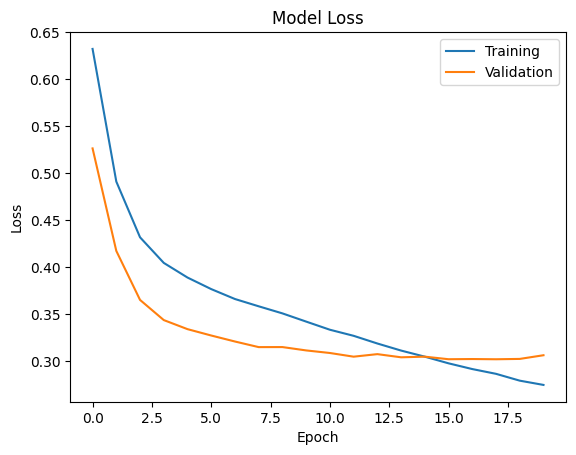

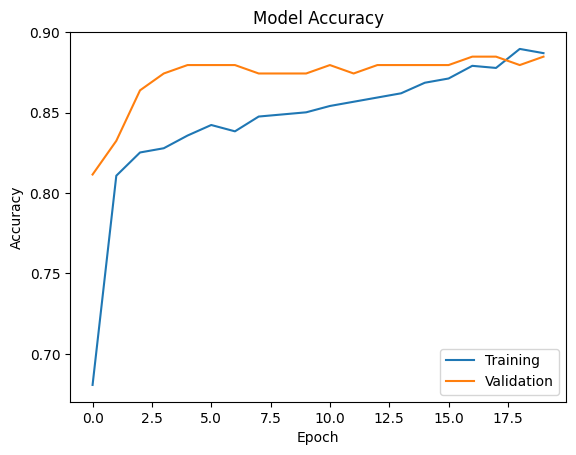

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [25]:
# Evaluate the model on the validation set
val_loss, val_acc = model_simple.evaluate(X_val, y_val, verbose=0)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)


# Plot training vs validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()


# Plot training vs validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()


# Optional: unified evaluation function (if you are using it elsewhere)
simple_fwd_nn = evaluate_model(
    model_simple,
    "simple_forward_NN",
    X_val,
    y_val
)


Confusion matrix for test set

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


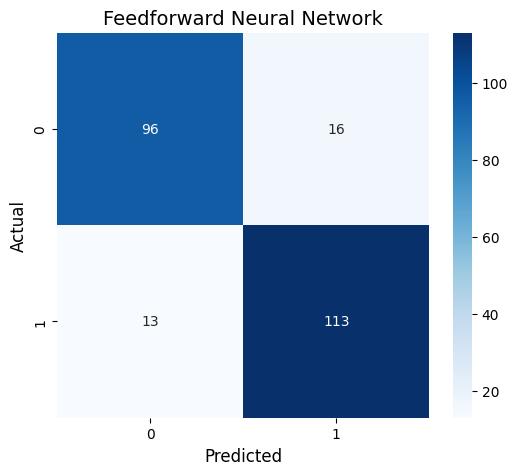

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict on TEST set
y_test_prob = model_simple.predict(X_test)

# Convert probabilities to class labels (0 or 1)
y_test_pred = (y_test_prob > 0.5).astype(int).ravel()
y_test_classes = y_test.values if hasattr(y_test, "values") else y_test

# Generate confusion matrix
cm_test = confusion_matrix(y_test_classes, y_test_pred)

# Display heatmap (same style as validation CM)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Feedforward Neural Network', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


Simple feedforward Neural Network using 0, 7, 123 and 2024 seed value

In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ------------------------------------------------------
# Data already prepared (FIXED – no leakage)
# X_tr, X_val, X_test
# y_tr, y_val, y_test
# ------------------------------------------------------

seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training FFNN with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Reproducibility
    # -----------------------------
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # -----------------------------
    # Build model (UNCHANGED)
    # -----------------------------
    model_simple = Sequential()
    model_simple.add(Dense(64, activation='relu', input_shape=(X_tr.shape[1],)))
    model_simple.add(Dense(32, activation='relu'))
    model_simple.add(Dense(1, activation='sigmoid'))

    model_simple.compile(
        optimizer=Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # -----------------------------
    # Train
    # -----------------------------
    model_simple.fit(
        X_tr, y_tr,
        epochs=32,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_prob = model_simple.predict(X_test, verbose=0)
    y_test_pred = (y_test_prob >= 0.5).astype(int).ravel()

    # -----------------------------
    # Metrics (same as other models)
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Test Metrics")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_ffnn = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option("display.precision", 10)

print("\n📊 FFNN – Seed Stability Results")
print(df_ffnn)

print("\n📈 Summary Statistics")
print(df_ffnn.describe())



 Training FFNN with seed = 0

Seed 0 – Test Metrics
Accuracy : 0.894958
Precision: 0.897638
Recall   : 0.904762
F1-score : 0.901186

 Training FFNN with seed = 7

Seed 7 – Test Metrics
Accuracy : 0.886555
Precision: 0.902439
Recall   : 0.880952
F1-score : 0.891566

 Training FFNN with seed = 123



Seed 123 – Test Metrics
Accuracy : 0.878151
Precision: 0.881890
Recall   : 0.888889
F1-score : 0.885375

 Training FFNN with seed = 2024



Seed 2024 – Test Metrics
Accuracy : 0.907563
Precision: 0.906250
Recall   : 0.920635
F1-score : 0.913386

📊 FFNN – Seed Stability Results
   Seed      Accuracy     Precision        Recall            F1
0     0  0.8949579832  0.8976377953  0.9047619048  0.9011857708
1     7  0.8865546218  0.9024390244  0.8809523810  0.8915662651
2   123  0.8781512605  0.8818897638  0.8888888889  0.8853754941
3  2024  0.9075630252  0.9062500000  0.9206349206  0.9133858268

📈 Summary Statistics
                  Seed      Accuracy     Precision        Recall            F1
count     4.0000000000  4.0000000000  4.0000000000  4.0000000000  4.0000000000
mean    538.5000000000  0.8918067227  0.8970541459  0.8988095238  0.8978783392
std     991.9383381373  0.0125465496  0.0107060696  0.0175980618  0.0122145363
min       0.0000000000  0.8781512605  0.8818897638  0.8809523810  0.8853754941
25%       5.2500000000  0.8844537815  0.8937007874  0.8869047619  0.8900185723
50%      65.0000000000  0.8907563025  0.90003

# ***CNN Model***

In [27]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Ensure all features are numeric for CNN
X_tr = X_tr.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)


#Reshape for Conv1D
X_tr_cnn  = X_tr.values.reshape(X_tr.shape[0], X_tr.shape[1], 1)
X_val_cnn = X_val.values.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)


#build CNN model
model_cnn = Sequential()

model_cnn.add(Conv1D(64, kernel_size=2, activation='relu',
                     input_shape=(X_tr_cnn.shape[1], 1)))
model_cnn.add(MaxPooling1D(pool_size=2))

model_cnn.add(Conv1D(128, kernel_size=2, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))

model_cnn.add(Flatten())
model_cnn.add(Dense(256, activation='relu'))
model_cnn.add(Dropout(0.1))
model_cnn.add(Dense(1, activation='sigmoid'))

model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_cnn = model_cnn.fit(
    X_tr_cnn, y_tr,
    epochs=32,
    batch_size=16,
    validation_data=(X_val_cnn, y_val),
    verbose=1
)

test_loss, test_acc = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.6f}")


Epoch 1/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.6324 - loss: 0.6182 - val_accuracy: 0.8639 - val_loss: 0.3887
Epoch 2/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8296 - loss: 0.4123 - val_accuracy: 0.8586 - val_loss: 0.3339
Epoch 3/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8609 - loss: 0.3703 - val_accuracy: 0.8639 - val_loss: 0.3207
Epoch 4/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8604 - loss: 0.3487 - val_accuracy: 0.8691 - val_loss: 0.3117
Epoch 5/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8555 - loss: 0.3378 - val_accuracy: 0.8743 - val_loss: 0.3007
Epoch 6/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8540 - loss: 0.3317 - val_accuracy: 0.8796 - val_loss: 0.3010
Epoch 7/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8640 - loss: 0.3194 - val_accuracy: 0.8743 - val_loss: 0.2986
Epoch 8/32
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8653 - loss: 0.3076 - val_accuracy: 0.8639 - val_loss

CNN Confusion matrix – Test Set

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
CNN – Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       112
           1       0.88      0.90      0.89       126

    accuracy                           0.88       238
   macro avg       0.88      0.88      0.88       238
weighted avg       0.88      0.88      0.88       238



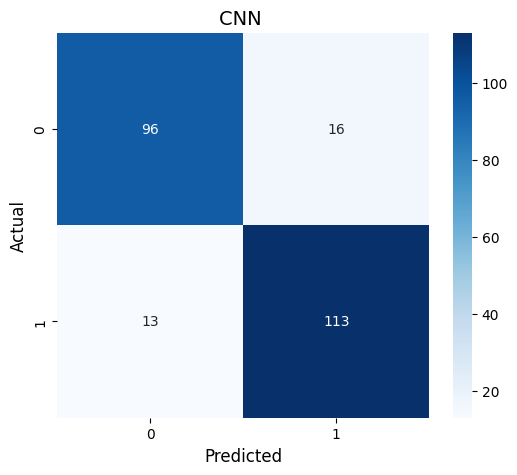

In [28]:
# Predict on TEST data
y_test_pred_prob = model_cnn.predict(X_test_cnn)
y_test_pred = (y_test_pred_prob > 0.5).astype(int).ravel()

# Classification Report (Test)
print("CNN – Test Classification Report:\n")
print(classification_report(y_test, y_test_pred, digits=2))

# Confusion Matrix (Test)
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('CNN ', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


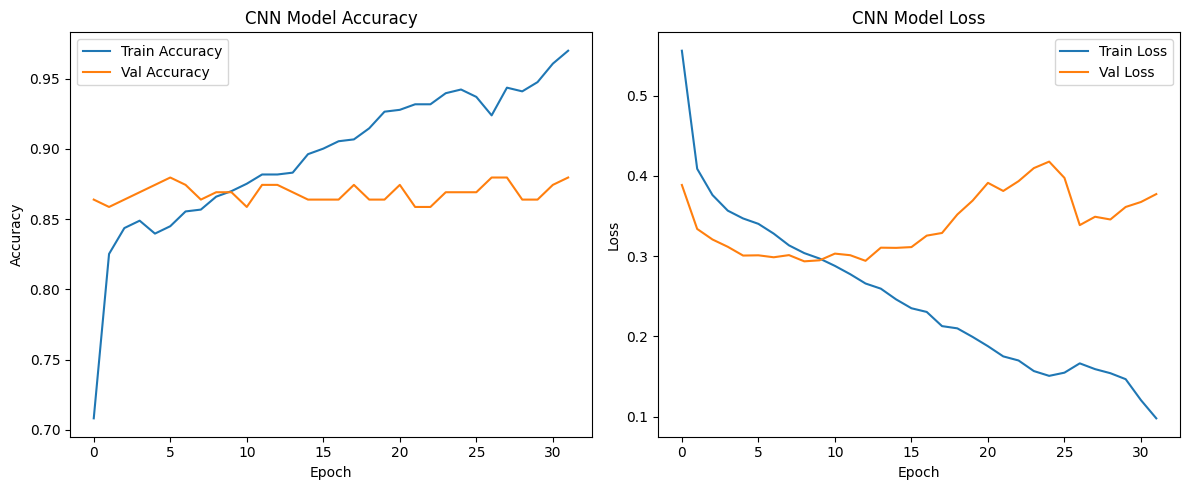

In [29]:
# Step 9: Plot accuracy and loss (CNN)
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


CNN using 0, 7, 123 and 2024 seed value

In [30]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ------------------------------------------------------
# Ensure all features are numeric for CNN
# ------------------------------------------------------
X_tr  = X_tr.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# ------------------------------------------------------
# Reshape for Conv1D
# ------------------------------------------------------
X_tr_cnn   = X_tr.values.reshape(X_tr.shape[0], X_tr.shape[1], 1)
X_val_cnn  = X_val.values.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

# ------------------------------------------------------
# Seeds for model randomness
# ------------------------------------------------------
seeds = [0, 7, 123, 2024]
results = []

for seed in seeds:

    print("\n===================================")
    print(f" Training CNN with seed = {seed}")
    print("===================================")

    # -----------------------------
    # Reproducibility
    # -----------------------------
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # -----------------------------
    # Build CNN model (UNCHANGED)
    # -----------------------------
    model_cnn = Sequential()

    model_cnn.add(Conv1D(
        64,
        kernel_size=2,
        activation='relu',
        input_shape=(X_tr_cnn.shape[1], 1)
    ))
    model_cnn.add(MaxPooling1D(pool_size=2))

    model_cnn.add(Conv1D(128, kernel_size=2, activation='relu'))
    model_cnn.add(MaxPooling1D(pool_size=2))

    model_cnn.add(Flatten())
    model_cnn.add(Dense(256, activation='relu'))
    model_cnn.add(Dropout(0.1))
    model_cnn.add(Dense(1, activation='sigmoid'))

    model_cnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # -----------------------------
    # Train
    # -----------------------------
    model_cnn.fit(
        X_tr_cnn, y_tr,
        epochs=32,
        batch_size=16,
        validation_data=(X_val_cnn, y_val),
        verbose=0
    )

    # -----------------------------
    # Test predictions
    # -----------------------------
    y_test_prob = model_cnn.predict(X_test_cnn, verbose=0)
    y_test_pred = (y_test_prob >= 0.5).astype(int).ravel()

    # -----------------------------
    # Metrics
    # -----------------------------
    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    print(f"\nSeed {seed} – Test Metrics")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")


# ------------------------------------------------------
# Results table
# ------------------------------------------------------
df_cnn = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option("display.precision", 10)

print("\n📊 CNN – Seed Stability Results")
print(df_cnn)

print("\n📈 Summary Statistics")
print(df_cnn.describe())



 Training CNN with seed = 0

Seed 0 – Test Metrics
Accuracy : 0.890756
Precision: 0.873134
Recall   : 0.928571
F1-score : 0.900000

 Training CNN with seed = 7

Seed 7 – Test Metrics
Accuracy : 0.857143
Precision: 0.802632
Recall   : 0.968254
F1-score : 0.877698

 Training CNN with seed = 123

Seed 123 – Test Metrics
Accuracy : 0.882353
Precision: 0.876923
Recall   : 0.904762
F1-score : 0.890625

 Training CNN with seed = 2024

Seed 2024 – Test Metrics
Accuracy : 0.882353
Precision: 0.895161
Recall   : 0.880952
F1-score : 0.888000

📊 CNN – Seed Stability Results
   Seed      Accuracy     Precision        Recall            F1
0     0  0.8907563025  0.8731343284  0.9285714286  0.9000000000
1     7  0.8571428571  0.8026315789  0.9682539683  0.8776978417
2   123  0.8823529412  0.8769230769  0.9047619048  0.8906250000
3  2024  0.8823529412  0.8951612903  0.8809523810  0.8880000000

📈 Summary Statistics
                  Seed      Accuracy     Precision        Recall            F1
count    

## **ML MODELS**

# **Stacking Algorithm**

In [31]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

base_models = [
    ('Random_Forest', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('ExtraTrees', ExtraTreesClassifier(
        n_estimators=550,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('DecisionTree', DecisionTreeClassifier(
        max_depth=7,
        random_state=42
    ))
]

lr_model = LogisticRegression(
    C=100,
    max_iter=100,
    penalty='l2',
    solver='liblinear',
    random_state=42
)

stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=lr_model,
    cv=5,                 # internal CV on TRAINING data only
    n_jobs=-1
)

stacking_classifier.fit(X_train, y_train)

y_train_pred = stacking_classifier.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.6f}")
y_test_pred = stacking_classifier.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.6f}")
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred))



Training Accuracy: 1.000000
Test Accuracy: 0.928571

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       112
           1       0.95      0.91      0.93       126

    accuracy                           0.93       238
   macro avg       0.93      0.93      0.93       238
weighted avg       0.93      0.93      0.93       238



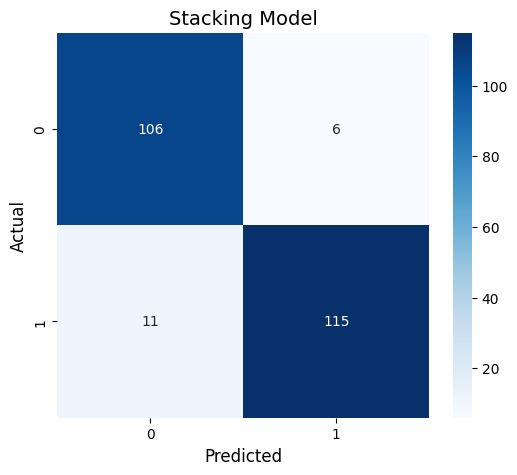

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on TEST set (use corrected variables)
y_test_pred = stacking_classifier.predict(X_test)

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrix (same style as other models)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Stacking Model', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()



**Stacking model using 0, 7, 123 and 2024 seed values**

In [33]:
import pandas as pd
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Seeds for model randomness (NOT data splitting)
seeds = [0, 7, 123, 2024]

results = []

for seed in seeds:

    # ================================
    # Base models (seed applied consistently)
    # ================================
    base_models = [
        ('Random_Forest', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=seed,
            n_jobs=-1
        )),
        ('ExtraTrees', ExtraTreesClassifier(
            n_estimators=550,
            max_depth=None,
            random_state=seed,
            n_jobs=-1
        )),
        ('DecisionTree', DecisionTreeClassifier(
            max_depth=7,
            random_state=seed
        ))
    ]

    # Meta-learner
    lr_model = LogisticRegression(
        C=100,
        max_iter=100,
        penalty='l2',
        solver='liblinear',
        random_state=seed
    )

    # Stacking classifier (internal CV on TRAINING data)
    stacking_classifier = StackingClassifier(
        estimators=base_models,
        final_estimator=lr_model,
        cv=5,
        n_jobs=-1
    )

    # ================================
    # Train on FIXED training set
    # ================================
    stacking_classifier.fit(X_train, y_train)

    # ================================
    # Evaluate on FIXED test set
    # ================================
    y_pred = stacking_classifier.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    df_stack = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)
print(df_stack)

print("\nSummary Statistics:")
print(df_stack.describe())



   Seed      Accuracy     Precision        Recall            F1
0     0  0.9369747899  0.9440000000  0.9365079365  0.9402390438
1     7  0.9327731092  0.9435483871  0.9285714286  0.9360000000
2   123  0.9369747899  0.9512195122  0.9285714286  0.9397590361
3  2024  0.9243697479  0.9426229508  0.9126984127  0.9274193548

Summary Statistics:
                  Seed      Accuracy     Precision        Recall            F1
count     4.0000000000  4.0000000000  4.0000000000  4.0000000000  4.0000000000
mean    538.5000000000  0.9327731092  0.9453477125  0.9265873016  0.9358543587
std     991.9383381373  0.0059420738  0.0039562718  0.0099865535  0.0059341518
min       0.0000000000  0.9243697479  0.9426229508  0.9126984127  0.9274193548
25%       5.2500000000  0.9306722689  0.9433170280  0.9246031746  0.9338548387
50%      65.0000000000  0.9348739496  0.9437741935  0.9285714286  0.9378795181
75%     598.2500000000  0.9369747899  0.9458048780  0.9305555556  0.9398790381
max    2024.0000000000  0.9

# **Decision Trees**

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Validation Accuracy: 0.8534

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.89      0.79      0.84        90
           1       0.83      0.91      0.87       101

    accuracy                           0.85       191
   macro avg       0.86      0.85      0.85       191
weighted avg       0.86      0.85      0.85       191


Test Accuracy: 0.8403

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       112
           1       0.84      0.86      0.85       126

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238



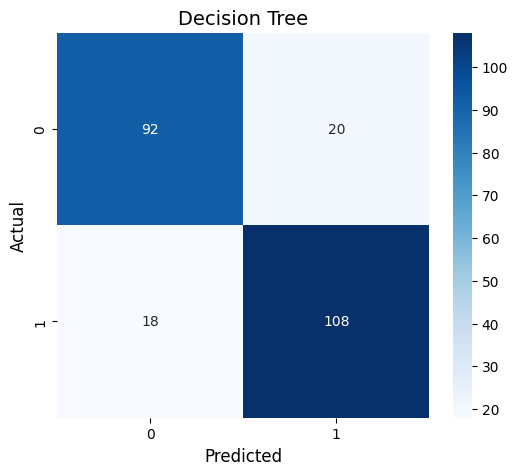

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_tr, y_tr)

best_dt = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

y_val_pred = best_dt.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

y_test_pred = best_dt.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Decision Tree', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()



**Decision Trees using 0, 7, 123 and 2024 seed values**

In [35]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# =========================================
# Seeds control MODEL randomness only
# (train–test split is FIXED)
# =========================================
seeds = [0, 7, 123, 2024]   # recommend increasing to 5+ later

# =========================================
# Hyperparameter grid
# =========================================
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

results = []

for seed in seeds:
    print(f"\n================ Seed {seed} ================")

    # Decision Tree with controlled randomness
    dt = DecisionTreeClassifier(random_state=seed)

    # GridSearchCV (STRICTLY on training data)
    grid_search = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    # Best model
    best_dt = grid_search.best_estimator_

    # ============================
    # FINAL evaluation on TEST set
    # ============================
    y_test_pred = best_dt.predict(X_test)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    # Optional diagnostic output
    print(f"Best Parameters: {grid_search.best_params_}")
    print(classification_report(y_test, y_test_pred))

# =========================================
# Results table
# =========================================
df_dt = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)

print("\n================ FINAL SUMMARY ================")
print(df_dt)

print("\nSummary Statistics:")
print(df_dt.describe())



================ Seed 0 ================
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       112
           1       0.91      0.91      0.91       126

    accuracy                           0.91       238
   macro avg       0.91      0.91      0.91       238
weighted avg       0.91      0.91      0.91       238


================ Seed 7 ================
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       112
           1       0.92      0.89      0.90       126

    accuracy                           0.90       238
   macro avg       0.90      0.90      0.90       238
weighted avg       0.90      0.90      0.90       238


================ Seed 123 ================
Best Par

# **Random Forest**

Training Accuracy: 0.8319327731092437
Test Accuracy: 0.8529411764705882

Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.824     0.875     0.848       112
           1      0.882     0.833     0.857       126

    accuracy                          0.853       238
   macro avg      0.853     0.854     0.853       238
weighted avg      0.855     0.853     0.853       238



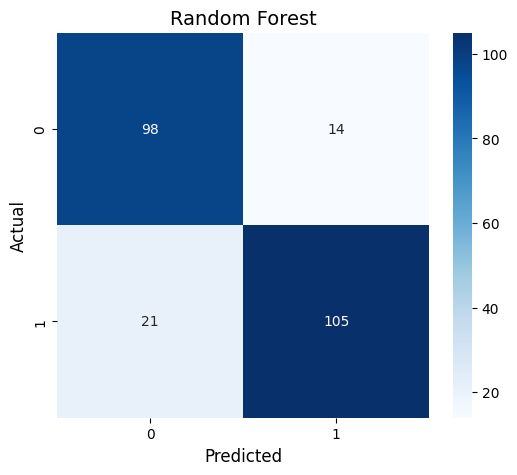

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Model (your regularized RF)
rf = RandomForestClassifier(
    n_estimators=100,
    min_impurity_decrease=0.01,
    bootstrap=True,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train on TRAINING data only
rf.fit(X_train, y_train)

# =========================================
# Diagnostic performance (training)
# =========================================
y_train_pred = rf.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

# =========================================
# FINAL evaluation on TEST set
# =========================================
y_test_pred = rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=3))

# =========================================
# Confusion Matrix (TEST SET ONLY)
# =========================================
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Random Forest', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


Random Forest using 0, 7, 123 and 2024 seed values

In [37]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Seeds control MODEL randomness only
# (train–test split is FIXED)
# =========================================
seeds = [0, 7, 123, 2024]   # increase to 5+ for stronger CI

results = []

for seed in seeds:
    print(f"\n================ Seed {seed} ================")

    # Random Forest model
    rf = RandomForestClassifier(
        n_estimators=100,
        min_impurity_decrease=0.01,
        bootstrap=True,
        random_state=seed,
        class_weight='balanced',
        n_jobs=-1
    )

    # Train on TRAINING data only
    rf.fit(X_train, y_train)

    # ============================
    # FINAL evaluation on TEST set
    # ============================
    y_test_pred = rf.predict(X_test)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    # Diagnostic output
    print(f"Test Accuracy: {acc:.6f}")
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))

# =========================================
# Results table
# =========================================
df_rf = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)

print("\n================ FINAL SUMMARY ================")
print(df_rf)

print("\nSummary Statistics:")
print(df_rf.describe())



================ Seed 0 ================
Test Accuracy: 0.840336

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       112
           1       0.87      0.83      0.85       126

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238


================ Seed 7 ================
Test Accuracy: 0.844538

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       112
           1       0.88      0.82      0.85       126

    accuracy                           0.84       238
   macro avg       0.85      0.85      0.84       238
weighted avg       0.85      0.84      0.84       238


================ Seed 123 ================
Test Accuracy: 0.865546

Classification Report (Test Set):
              precision    recall  f1-sco

# **Logistic regression**

Test Accuracy: 0.857143

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       112
           1       0.85      0.88      0.87       126

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238



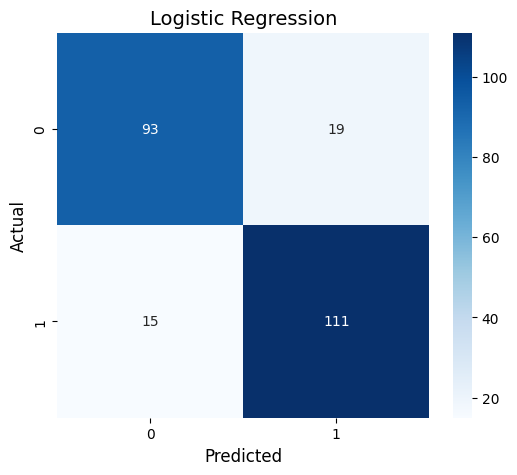

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Logistic Regression (FIXED train–test split)
# =========================================

# Standardize features (FIT on TRAIN only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Logistic Regression model
logreg = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='saga',
    random_state=42
)

# Train on TRAINING data only
logreg.fit(X_train_scaled, y_train)

# ============================
# FINAL evaluation on TEST set
# ============================
y_test_pred = logreg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy:.6f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# ============================
# Confusion Matrix (TEST SET)
# ============================
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('Logistic Regression', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


Logistic Regression Using 0, 7, 123 and 2024 seed value

In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# =========================================
# Seeds control MODEL randomness only
# (train–test split is FIXED)
# =========================================
seeds = [0, 7, 123, 2024]   # increase to 5+ for stronger CI

results = []

for seed in seeds:
    print(f"\n================ Seed {seed} ================")

    # -----------------------------
    # 1. Standardization
    # (fit ONLY on TRAINING data)
    # -----------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # -----------------------------
    # 2. Logistic Regression (L1)
    # -----------------------------
    logreg = LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=1000,
        random_state=seed
    )

    # Train on TRAINING data only
    logreg.fit(X_train_scaled, y_train)

    # -----------------------------
    # 3. FINAL evaluation on TEST set
    # -----------------------------
    y_test_pred = logreg.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    # Optional diagnostic output
    print(f"Test Accuracy: {acc:.6f}")
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))

# ==================================
# Final results summary
# ==================================
df_logreg = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)

print("\n================ FINAL SUMMARY ================")
print(df_logreg)

print("\nSummary Statistics:")
print(df_logreg.describe())



================ Seed 0 ================
Test Accuracy: 0.857143

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       112
           1       0.85      0.88      0.87       126

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238


================ Seed 7 ================
Test Accuracy: 0.857143

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       112
           1       0.85      0.88      0.87       126

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238


================ Seed 123 ================
Test Accuracy: 0.857143

Classification Report (Test Set):
              precision    recall  f1-sco

# **XGBoost**

Test Accuracy: 0.836134

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       112
           1       0.87      0.82      0.84       126

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238



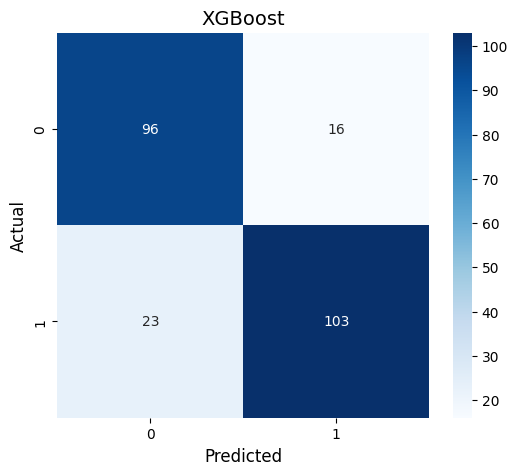

In [40]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================
# XGBoost (FIXED train–test split)
# =========================================

# XGBoost model
xg_model = xgb.XGBClassifier(
    max_depth=3,
    learning_rate=0.001,
    n_estimators=300,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train on TRAINING data only
xg_model.fit(X_train, y_train)

# ============================
# FINAL evaluation on TEST set
# ============================
y_test_pred = xg_model.predict(X_test)

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Test Accuracy: {acc:.6f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# ============================
# Confusion Matrix (TEST SET)
# ============================
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title('XGBoost', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


XGboost using 0, 7, 123 and 2024 seed value

In [41]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Seeds control MODEL randomness only
# (train–test split is FIXED)
# =========================================
seeds = [0, 7, 123, 2024]   # increase to 5+ for stronger CI

results = []

for seed in seeds:
    print(f"\n================ Seed {seed} ================")

    # XGBoost model
    xg_model = xgb.XGBClassifier(
        max_depth=3,
        learning_rate=0.001,
        n_estimators=300,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=seed,
        n_jobs=-1
    )

    # Train on TRAINING data only
    xg_model.fit(X_train, y_train)

    # ============================
    # FINAL evaluation on TEST set
    # ============================
    y_test_pred = xg_model.predict(X_test)

    acc  = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec  = recall_score(y_test, y_test_pred, zero_division=0)
    f1   = f1_score(y_test, y_test_pred, zero_division=0)

    results.append([seed, acc, prec, rec, f1])

    # Diagnostic output
    print(f"Test Accuracy: {acc:.6f}")
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))

# Results table

df_xgb = pd.DataFrame(
    results,
    columns=["Seed", "Accuracy", "Precision", "Recall", "F1"]
)

pd.set_option('display.precision', 10)

print("\n================ FINAL SUMMARY ================")
print(df_xgb)

print("\nSummary Statistics:")
print(df_xgb.describe())



================ Seed 0 ================
Test Accuracy: 0.836134

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       112
           1       0.87      0.82      0.84       126

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238


================ Seed 7 ================
Test Accuracy: 0.836134

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       112
           1       0.87      0.82      0.84       126

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238


================ Seed 123 ================
Test Accuracy: 0.836134

Classification Report (Test Set):
              precision    recall  f1-sco

# **95% CI for top models using 0, 7, 42, 123 and 2024 seed value**

In [42]:
import pandas as pd
import numpy as np
from scipy import stats

# =========================================
# Helper function to compute CI
# =========================================
def compute_ci(series, confidence=0.95):
    mean = series.mean()
    std = series.std(ddof=1)
    n = series.count()

    if n > 1:
        h = stats.t.ppf((1 + confidence) / 2, n - 1) * std / np.sqrt(n)
    else:
        h = 0.0

    return mean, std, mean - h, mean + h


# =========================================
# Collect all model result DataFrames
# =========================================
model_results = {
    "Decision Tree": df_dt,
    "Random Forest": df_rf,
    "Logistic Regression": df_logreg,
    "XGBoost": df_xgb,
    "Stacking": df_stack,
    "CNN": df_cnn,
    "FFNN": df_ffnn,

}

metrics = ["Accuracy", "Precision", "Recall", "F1"]

summary_rows = []

# =========================================
# Build CI table
# =========================================
for model_name, df_model in model_results.items():
    row = {"Model": model_name}

    for metric in metrics:
        mean, std, ci_low, ci_high = compute_ci(df_model[metric])

        row[f"{metric}_Mean"] = mean
        row[f"{metric}_SD"] = std
        row[f"{metric}_CI_Lower"] = ci_low
        row[f"{metric}_CI_Upper"] = ci_high

    summary_rows.append(row)

# =========================================
# Final CI table
# =========================================
df_ci = pd.DataFrame(summary_rows)

pd.set_option("display.precision", 4)
print("\n================ CI SUMMARY TABLE ================")
print(df_ci)



================ CI SUMMARY TABLE ================
                 Model  Accuracy_Mean  Accuracy_SD  Accuracy_CI_Lower  \
0        Decision Tree         0.9013       0.0042             0.8946   
1        Random Forest         0.8424       0.0189             0.8123   
2  Logistic Regression         0.8571       0.0000             0.8571   
3              XGBoost         0.8361       0.0000             0.8361   
4             Stacking         0.9328       0.0059             0.9233   
5                  CNN         0.8782       0.0146             0.8550   
6                 FFNN         0.8918       0.0125             0.8718   

   Accuracy_CI_Upper  Precision_Mean  Precision_SD  Precision_CI_Lower  \
0             0.9079          0.9133        0.0032              0.9082   
1             0.8726          0.8735        0.0056              0.8646   
2             0.8571          0.8538        0.0000              0.8538   
3             0.8361          0.8655        0.0000              0.8

# **McNemar Tests**

In [ ]:
# Generate and STORE test-set predictions ONCE per model

y_pred_dt = best_dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_xgb = xg_model.predict(X_test)
y_pred_stack = stacking_classifier.predict(X_test)

# Feedforward Neural Network predictions (TEST SET)
y_pred_nn_prob = model_simple.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).ravel()

# Prepare CNN test input (same shape as training)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

# CNN predictions (TEST SET)
y_pred_cnn_prob = model_cnn.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int).ravel()


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [ ]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

# =================================================
# Test-set ground truth
# =================================================
y_true = y_test.values if hasattr(y_test, "values") else y_test

# =================================================
# Store TEST-SET PREDICTIONS (arrays, not tables)
# =================================================
predictions = {
    "Decision Tree": y_pred_dt,
    "Random Forest":y_pred_rf,
    "Logistic Regression": y_pred_logreg,
    "XGBoost": y_pred_xgb ,
    "Stacking": y_pred_stack,
    "Feedforward NN": y_pred_nn,
    "CNN": y_pred_cnn
}

# =================================================
# McNemar test function
# =================================================
def run_mcnemar(y_true, y_pred_a, y_pred_b):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred_a = pd.Series(y_pred_a).reset_index(drop=True)
    y_pred_b = pd.Series(y_pred_b).reset_index(drop=True)

    b = ((y_pred_a == y_true) & (y_pred_b != y_true)).sum()
    c = ((y_pred_a != y_true) & (y_pred_b == y_true)).sum()

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=False, correction=True)
    return b, c, result.statistic, result.pvalue

# =================================================
# Run pairwise McNemar tests
# (use best model as reference)
# =================================================
reference_model = "Stacking"
results = []

for model_name, y_pred in predictions.items():
    if model_name == reference_model:
        continue

    b, c, chi2, p = run_mcnemar(
        y_true,
        predictions[reference_model],
        y_pred
    )

    results.append([
        reference_model,
        model_name,
        b,
        c,
        chi2,
        p
    ])

# =================================================
# Results table
# =================================================
df_mcnemar = pd.DataFrame(
    results,
    columns=[
        "Model_A",
        "Model_B",
        "A_correct_B_wrong (b)",
        "A_wrong_B_correct (c)",
        "Chi_square",
        "p_value"
    ]
)

pd.set_option("display.precision", 6)

print("\n================ McNemar Test Results ================")
print(df_mcnemar)



================ McNemar Test Results ================
    Model_A              Model_B  A_correct_B_wrong (b)  \
0  Stacking        Decision Tree                      9   
1  Stacking        Random Forest                     22   
2  Stacking  Logistic Regression                     22   
3  Stacking              XGBoost                     25   
4  Stacking       Feedforward NN                     18   
5  Stacking                  CNN                     12   

   A_wrong_B_correct (c)  Chi_square   p_value  
0                      5    0.642857  0.422678  
1                      7    6.758621  0.009330  
2                      7    6.758621  0.009330  
3                      6   10.451613  0.001225  
4                      8    3.115385  0.077556  
5                      6    1.388889  0.238593  


“Pairwise statistical comparisons were conducted using McNemar’s test on the held-out test set. The stacking classifier demonstrated statistically significant improvements over Random Forest (p = 0.009), Logistic Regression (p = 0.009), and XGBoost (p = 0.001). Although stacking achieved higher correct classification counts than Decision Tree, Feedforward Neural Network, and CNN models, these differences were not statistically significant (p > 0.05).”

# **TabNet**

In [ ]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00


epoch 0  | loss: 1.49802 | val_0_accuracy: 0.51261 |  0:00:00s
epoch 10 | loss: 0.53994 | val_0_accuracy: 0.7395  |  0:00:04s
epoch 20 | loss: 0.41385 | val_0_accuracy: 0.81513 |  0:00:07s
epoch 30 | loss: 0.37158 | val_0_accuracy: 0.83193 |  0:00:09s
epoch 40 | loss: 0.34429 | val_0_accuracy: 0.84454 |  0:00:14s

Early stopping occurred at epoch 47 with best_epoch = 37 and best_val_0_accuracy = 0.87395
TabNet Test Accuracy: 0.873950

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       112
           1       0.86      0.91      0.88       126

    accuracy                           0.87       238
   macro avg       0.88      0.87      0.87       238
weighted avg       0.88      0.87      0.87       238



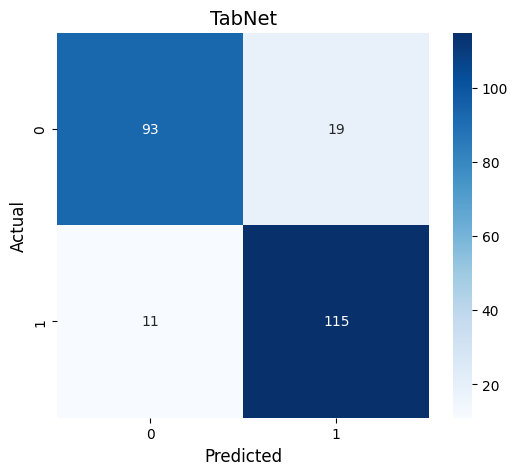

In [ ]:
import numpy as np
import torch
import pandas as pd
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# TabNet requires numpy float32 inputs
# Use FIXED train–test split
# =========================================
X_train_tab = X_train.values.astype(np.float32)
X_test_tab  = X_test.values.astype(np.float32)
y_train_tab = y_train.values.astype(np.int64)
y_test_tab  = y_test.values.astype(np.int64)

# =========================================
# TabNet model
# =========================================
tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    mask_type='entmax',
    seed=42,
    verbose=10
)

# =========================================
# Train (validation used ONLY for early stopping)
# =========================================
tabnet.fit(
    X_train_tab,
    y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

# =========================================
# FINAL evaluation on TEST set
# =========================================
y_pred_tab = tabnet.predict(X_test_tab)

acc = accuracy_score(y_test_tab, y_pred_tab)
print(f"TabNet Test Accuracy: {acc:.6f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_tab, y_pred_tab))

# =========================================
# Confusion Matrix (TEST SET)
# =========================================
cm_tab = confusion_matrix(y_test_tab, y_pred_tab)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tab,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("TabNet", fontsize=14)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# =========================================
# Helper function for CI
# =========================================
def compute_ci(series, confidence=0.95):
    mean = series.mean()
    std = series.std(ddof=1)
    n = series.count()

    if n > 1:
        h = stats.t.ppf((1 + confidence) / 2, n - 1) * std / np.sqrt(n)
    else:
        h = 0.0

    return mean, std, mean - h, mean + h


# =========================================
# Model accuracy result DataFrames
# (already created earlier)
# =========================================
accuracy_results = {
    "Decision Tree": df_dt["Accuracy"],
    "Random Forest": df_rf["Accuracy"],
    "Logistic Regression": df_logreg["Accuracy"],
    "XGBoost": df_xgb["Accuracy"],
    "Stacking": df_stack["Accuracy"],
}

rows = []

for model, acc_series in accuracy_results.items():
    if acc_series is None:
        continue

    mean, std, ci_low, ci_high = compute_ci(acc_series)

    rows.append({
        "Model": model,
        "Accuracy (Mean)": mean,
        "Std Dev": std,
        "95% CI Lower": ci_low,
        "95% CI Upper": ci_high
    })

# =========================================
# Final accuracy comparison table
# =========================================
df_accuracy_comparison = pd.DataFrame(rows)

pd.set_option("display.precision", 4)

print("\n================ ACCURACY COMPARISON TABLE ================")
print(df_accuracy_comparison.sort_values("Accuracy (Mean)", ascending=False))



================ ACCURACY COMPARISON TABLE ================
                 Model  Accuracy (Mean)  Std Dev  95% CI Lower  95% CI Upper
4             Stacking           0.9160   0.0059        0.8626        0.9694
0        Decision Tree           0.8992   0.0059        0.8458        0.9525
2  Logistic Regression           0.8487   0.0000        0.8487        0.8487
1        Random Forest           0.8445   0.0059        0.7912        0.8979
3              XGBoost           0.8319   0.0000        0.8319        0.8319
